In [108]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from qutip import rand_dm, Qobj, fidelity, rand_ket
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import copy
import optuna

## Generazione dataset

In [ ]:
z0 = np.array([[1], [0]])
z1 = np.array([[0], [1]])

x0 = (z0 + z1) / np.sqrt(2)
x1 = (z0 - z1) / np.sqrt(2)

y0 = (z0 + 1j*z1) / np.sqrt(2)
y1 = (z0 - 1j*z1) / np.sqrt(2)

basi_qubit = {
    'Z': [z0, z1],
    'X': [x0, x1],
    'Y': [y0, y1]
}

# 9 basi accoppiate per 2 Qubit (ZZ, ZX, ZY, XZ, XX, XY, YZ, YX, YY)
# Ciascuna base contiene i 4 proiettori ortogonali associati agli esiti 00, 01, 10, 11
basi_2q = []
for b1 in ['Z', 'X', 'Y']:
    for b2 in ['Z', 'X', 'Y']:
        proiettori_base = []
        for v1 in basi_qubit[b1]:
            for v2 in basi_qubit[b2]:
                psi_2q = np.kron(v1, v2)
                proiettore = psi_2q @ psi_2q.conj().T  
                proiettori_base.append(proiettore)
        basi_2q.append(proiettori_base) 

NUM_ESEMPI = 2000
NUM_SHOTS = 1024

X_lista = []
y_lista = []

print(f"Generazione dataset: {NUM_ESEMPI} stati a 2 Qubit con {NUM_SHOTS} misure per base")

for i in range(NUM_ESEMPI):
    psi1 = rand_ket(2).full() 
    psi2 = rand_ket(2).full() 
    
    psi_2q = np.kron(psi1, psi2) 
    rho_puro = psi_2q @ psi_2q.conj().T
    
    p_rumore = np.random.uniform(0.0, 0.30)
    rho_matrice = (1 - p_rumore) * rho_puro + p_rumore * (np.eye(4) / 4) #rho = (1-p)*|psi><psi| + p*(I/4) 
    
    misurazioni_sperimentali = []
    
    for proiettori_base in basi_2q:
        probabilita_base = []
        
        for P in proiettori_base:
            prob = np.real(np.trace(rho_matrice @ P))
            probabilita_base.append(prob)

        probabilita_base = np.array(probabilita_base)
        probabilita_base /= np.sum(probabilita_base)
        
        conteggi_esiti = np.random.multinomial(NUM_SHOTS, probabilita_base)

        frequenze_esiti = conteggi_esiti / NUM_SHOTS
        misurazioni_sperimentali.extend(frequenze_esiti)
        
    X_lista.append(misurazioni_sperimentali)
    rho_piatta = np.concatenate([rho_matrice.real.flatten(), rho_matrice.imag.flatten()])
    y_lista.append(rho_piatta)

X = torch.tensor(np.array(X_lista), dtype=torch.float32)
Y = torch.tensor(np.array(y_lista), dtype=torch.float32)

print("\n--- GENERAZIONE COMPLETATA CON SUCCESSO ---")
print(f"Input X (Features):   {X.shape} -> (5000 esempi, 36 frequenze misurate distribuite su 9 basi)")
print(f"Target Y (Labels):    {Y.shape} -> (5000 esempi, 32 componenti reali/immaginarie di rho)")

Generazione dataset: 2000 stati a 2 Qubit (Approccio Multinomiale)...

--- GENERAZIONE COMPLETATA CON SUCCESSO ---
Input X (Features):   torch.Size([2000, 36]) -> (5000 esempi, 36 frequenze misurate distribuite su 9 basi)
Target Y (Labels):    torch.Size([2000, 32]) -> (5000 esempi, 32 componenti reali/immaginarie di rho)


## Fidelity

In [110]:
def calcola_fidelity_modello(y_vero_flat, y_predetto_flat):
    """Calcola la Fidelity tra il target (vero) e l'output della rete (predetto)"""
    
    vero_complex = y_vero_flat[:16] + 1j * y_vero_flat[16:]
    pred_complex = y_predetto_flat[:16] + 1j * y_predetto_flat[16:]
    
    rho_vera = Qobj(vero_complex.reshape(4, 4), dims=[[2, 2], [2, 2]])
    rho_pred = Qobj(pred_complex.reshape(4, 4), dims=[[2, 2], [2, 2]])
    
    return fidelity(rho_vera, rho_pred)

### Caratterizzazione del dataset

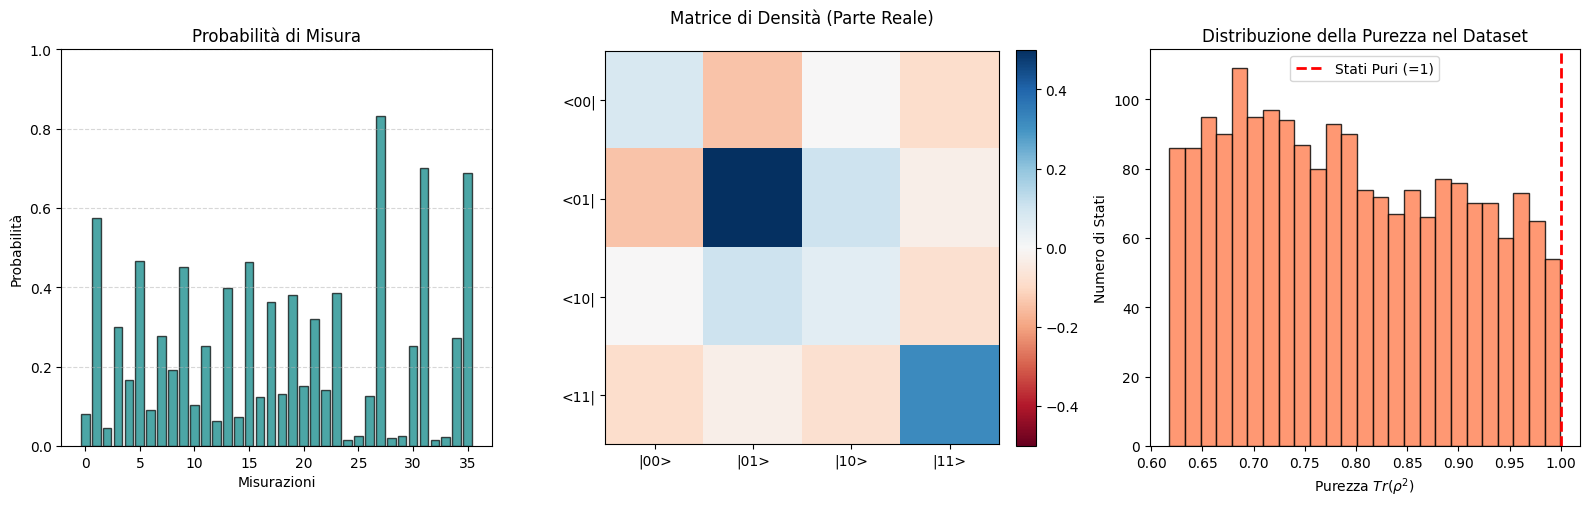

In [ ]:
indice = 0
misurazioni = X[indice].numpy() 
matrice_flat = Y[indice].numpy()

rho_real = matrice_flat[:16].reshape(4, 4)
rho_imag = matrice_flat[16:].reshape(4, 4)

fig = plt.figure(figsize=(16, 5))

ax1 = fig.add_subplot(1, 3, 1)
ax1.bar(range(36), misurazioni, color='teal', alpha=0.7, edgecolor='black')
ax1.set_title("Probabilità di Misura", fontsize=12)
ax1.set_xlabel("Misurazioni")
ax1.set_ylabel("Probabilità")
ax1.set_ylim(0, 1)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

ax2 = fig.add_subplot(1, 3, 2)
cax = ax2.matshow(rho_real, cmap='RdBu', vmin=-0.5, vmax=0.5)
ax2.set_title("Matrice di Densità (Parte Reale)", fontsize=12, pad=20)
ax2.set_xticks(range(4))
ax2.set_yticks(range(4))
ax2.set_xticklabels(['|00>', '|01>', '|10>', '|11>'])
ax2.set_yticklabels(['<00|', '<01|', '<10|', '<11|'])
ax2.xaxis.set_ticks_position('bottom')
fig.colorbar(cax, ax=ax2, fraction=0.046, pad=0.04)

purezze = []
for y in Y.numpy():
    c_mat = (y[:16] + 1j * y[16:]).reshape(4, 4)
    purezza = np.real(np.trace(c_mat @ c_mat))
    purezze.append(purezza)

ax3 = fig.add_subplot(1, 3, 3)
ax3.hist(purezze, bins=25, color='coral', edgecolor='black', alpha=0.8)
ax3.set_title("Distribuzione della Purezza nel Dataset", fontsize=12)
ax3.set_xlabel(r"Purezza $Tr(\rho^2)$")
ax3.set_ylabel("Numero di Stati")
ax3.axvline(1.0, color='red', linestyle='dashed', linewidth=2, label='Stati Puri (=1)')
ax3.legend()

plt.tight_layout()
plt.savefig("Immagini/dataset_qst.pdf", format='pdf')
plt.show()

## Costruzione della rete
### Layer fisici

In [ ]:
class DensityMatrixLayer(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):

        batch_size = x.shape[0]

        T = torch.zeros((batch_size, 4, 4), dtype=torch.complex64, device=x.device) 
        
        T[:, 0, 0] = torch.exp(x[:, 0]) + 0j
        T[:, 1, 1] = torch.exp(x[:, 1]) + 0j
        T[:, 2, 2] = torch.exp(x[:, 2]) + 0j
        T[:, 3, 3] = torch.exp(x[:, 3]) + 0j

        T[:, 1, 0] = x[:, 4] + 1j * x[:, 5]
        T[:, 2, 0] = x[:, 6] + 1j * x[:, 7]
        T[:, 2, 1] = x[:, 8] + 1j * x[:, 9]
        T[:, 3, 0] = x[:, 10] + 1j * x[:, 11]
        T[:, 3, 1] = x[:, 12] + 1j * x[:, 13]
        T[:, 3, 2] = x[:, 14] + 1j * x[:, 15]

        T_dagger = T.conj().transpose(1, 2)
        rho = torch.bmm(T, T_dagger)

        traccia = torch.diagonal(rho, dim1=-2, dim2=-1).sum(-1).real
        traccia = traccia.view(batch_size, 1, 1) + 0j 

        rho_norm = rho / traccia
        
        return rho_norm

class ExpectationLayer(nn.Module):
    def __init__(self, proiettori):
        super().__init__()
        self.proiettori = torch.tensor(np.array(proiettori), dtype=torch.complex64)

    def forward(self, rho):
        misurazioni_generate = torch.einsum('bij,nji->bn', rho, self.proiettori).real
        return misurazioni_generate

### Early stop

In [ ]:
class EarlyStopping:
    def __init__(self, patience=100, min_delta=0.0):
        self.patience = patience 
        self.min_delta = min_delta
        self.counter = 0 
        self.best_loss = float('inf')
        self.early_stop = False 
        self.best_model_G_weights = None

    def __call__(self, val_loss, generatore):

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_model_G_weights = copy.deepcopy(generatore.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

### Generatore e discriminatore

In [ ]:
class Generator(nn.Module):
    def __init__(self, proiettori, nodi_nascosti=128):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(36, nodi_nascosti),
            nn.ReLU(),
            nn.Linear(nodi_nascosti, nodi_nascosti),
            nn.ReLU(),
            nn.Linear(nodi_nascosti, 16) 
        )

        self.density_matrix_layer = DensityMatrixLayer()
        self.expectation_layer = ExpectationLayer(proiettori)

    def forward(self, x):

        parametri_t = self.net(x)
    
        rho_generata = self.density_matrix_layer(parametri_t)

        misurazioni_generate = self.expectation_layer(rho_generata)
        
        return rho_generata, misurazioni_generate


class Discriminator(nn.Module):
    def __init__(self, nodi_nascosti=128):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(72, nodi_nascosti),
            nn.LeakyReLU(0.2),
            nn.Linear(nodi_nascosti, nodi_nascosti // 2),
            nn.LeakyReLU(0.2),
            nn.Linear(nodi_nascosti // 2, 1),
            nn.Sigmoid() 
        )

    def forward(self, misurazioni_vere_condizione, misurazioni_da_valutare):

        x = torch.cat([misurazioni_vere_condizione, misurazioni_da_valutare], dim=1)
        return self.net(x)

proiettori_allineati = [P for proiettori_base in basi_2q for P in proiettori_base]

generatore = Generator(proiettori_allineati)
discriminatore = Discriminator()

print("QST-CGAN inizializzata con successo")

QST-CGAN inizializzata con successo!


### Dataset di train, validation e test

In [115]:
X_train, X_temp, y_train, y_temp = train_test_split(X, Y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Dati di Train (70%):      {X_train.shape[0]} campioni")
print(f"Dati di Validation (15%): {X_val.shape[0]} campioni")
print(f"Dati di Test (15%):       {X_test.shape[0]} campioni")

dataset_train = TensorDataset(X_train, y_train)
dataset_val = TensorDataset(X_val, y_val)
dataset_test = TensorDataset(X_test, y_test)

dataloader_train = DataLoader(dataset_train, batch_size=50, shuffle=True)
dataloader_val = DataLoader(dataset_val, batch_size=50, shuffle=False)
dataloader_test = DataLoader(dataset_test, batch_size=50, shuffle=False)

Dati di Train (70%):      1400 campioni
Dati di Validation (15%): 300 campioni
Dati di Test (15%):       300 campioni


### Studio numero di nodi

In [116]:
def objective_architettura(trial):

    nodi_G = trial.suggest_categorical("nodi_G", [64, 128, 256, 512])
    nodi_D = trial.suggest_categorical("nodi_D", [32, 64, 128, 256])
    
    lr_G_fisso = 0.0001
    lr_D_fisso = 0.00005
    beta1_fisso = 0.5
    lambda_fisso = 5.0  
    
    generatore_trial = Generator(proiettori_allineati, nodi_nascosti=nodi_G)
    discriminatore_trial = Discriminator(nodi_nascosti=nodi_D)
    
    opt_G_trial = optim.Adam(generatore_trial.parameters(), lr=lr_G_fisso, betas=(beta1_fisso, 0.999))
    opt_D_trial = optim.Adam(discriminatore_trial.parameters(), lr=lr_D_fisso, betas=(beta1_fisso, 0.999))
    criterio_gan = nn.BCELoss()

    EPOCHS_TRIAL = 100 

    for epoca in range(EPOCHS_TRIAL):
        generatore_trial.train()
        discriminatore_trial.train()
        
        for batch_X, batch_y in dataloader_train:
            rho_vera = (batch_y[:, :16] + 1j * batch_y[:, 16:]).reshape(-1, 4, 4)
            etichette_vere = torch.ones((batch_X.size(0), 1), device=batch_X.device)
            etichette_false = torch.zeros((batch_X.size(0), 1), device=batch_X.device)

            opt_D_trial.zero_grad()
            pred_vero = discriminatore_trial(batch_X, batch_X) 
            loss_D_vero = criterio_gan(pred_vero, etichette_vere)
            rho_gen, misurazioni_gen = generatore_trial(batch_X)
            pred_falso = discriminatore_trial(batch_X, misurazioni_gen.detach())
            loss_D_falso = criterio_gan(pred_falso, etichette_false)
            loss_D = (loss_D_vero + loss_D_falso) / 2
            loss_D.backward()
            opt_D_trial.step()

            opt_G_trial.zero_grad() 
            rho_gen_aggiornato, misurazioni_gen_aggiornate = generatore_trial(batch_X)
            pred_inganno = discriminatore_trial(batch_X, misurazioni_gen_aggiornate)
            loss_G_adv = criterio_gan(pred_inganno, etichette_vere)
            
            errore_reale_L1 = torch.mean(torch.abs(rho_vera.real - rho_gen_aggiornato.real))
            errore_immag_L1 = torch.mean(torch.abs(rho_vera.imag - rho_gen_aggiornato.imag))
            loss_fisica = errore_reale_L1 + errore_immag_L1
            
            loss_G_totale = loss_G_adv + (lambda_fisso * loss_fisica)
            loss_G_totale.backward()
            opt_G_trial.step()

        generatore_trial.eval()
        errore_val_epoca = 0.0
        
        with torch.no_grad(): 
            for batch_X_val, batch_y_val in dataloader_val:
                rho_vera_v = (batch_y_val[:, :16] + 1j * batch_y_val[:, 16:]).reshape(-1, 4, 4)
                rho_gen_v, _ = generatore_trial(batch_X_val)
                
                err_v_reale = torch.mean((rho_vera_v.real - rho_gen_v.real)**2)
                err_v_immag = torch.mean((rho_vera_v.imag - rho_gen_v.imag)**2)
                errore_val_epoca += (err_v_reale + err_v_immag).item()
                
        errore_medio_val = errore_val_epoca / len(dataloader_val)
        
        trial.report(errore_medio_val, epoca)
        
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return errore_medio_val 

print("Inizio Fase 1: Ricerca dell'architettura ideale...")
optuna.logging.set_verbosity(optuna.logging.WARNING) 

study_architettura = optuna.create_study(direction="minimize")
study_architettura.optimize(objective_architettura, n_trials=20, show_progress_bar=True) 

print("L'architettura migliore trovata è:")
print(f"-> Nodi Generatore: {study_architettura.best_params['nodi_G']}")
print(f"-> Nodi Discriminatore: {study_architettura.best_params['nodi_D']}")
print(f"Con MSE di validazione a 30 epoche pari a: {study_architettura.best_value:.6f}")

Inizio Fase 1: Ricerca dell'architettura ideale...


Best trial: 13. Best value: 0.000270544: 100%|██████████| 20/20 [01:32<00:00,  4.62s/it]

L'architettura migliore trovata è:
-> Nodi Generatore: 512
-> Nodi Discriminatore: 128
Con MSE di validazione a 30 epoche pari a: 0.000271


### Studio parametri

In [ ]:
nodi_nascosti_G_ottimale = study_architettura.best_params['nodi_G']
nodi_nascosti_D_ottimale = study_architettura.best_params['nodi_D']

def objective(trial):

    lr_G_prova = trial.suggest_float("lr_G", 1e-5, 1e-3, log=True)
    lr_D_prova = trial.suggest_float("lr_D", 1e-6, 1e-4, log=True)
    lambda_prova = trial.suggest_float("lambda_fisica", 1.0, 20.0)
    
    generatore_trial = Generator(proiettori_allineati, nodi_nascosti=nodi_nascosti_G_ottimale)
    discriminatore_trial = Discriminator(nodi_nascosti=nodi_nascosti_D_ottimale)
    
    opt_G_trial = optim.Adam(generatore_trial.parameters(), lr=lr_G_prova, betas=(0.5, 0.999))
    opt_D_trial = optim.Adam(discriminatore_trial.parameters(), lr=lr_D_prova, betas=(0.5, 0.999))
    criterio_gan = nn.BCELoss()
    
    EPOCHS_TRIAL = 50 
    
    for epoca in range(EPOCHS_TRIAL):
        
        generatore_trial.train()
        discriminatore_trial.train()
        
        for batch_X, batch_y in dataloader_train:
            rho_vera = (batch_y[:, :16] + 1j * batch_y[:, 16:]).reshape(-1, 4, 4)
            etichette_vere = torch.ones((batch_X.size(0), 1), device=batch_X.device)
            etichette_false = torch.zeros((batch_X.size(0), 1), device=batch_X.device)

            opt_D_trial.zero_grad()
            pred_vero = discriminatore_trial(batch_X, batch_X) 
            loss_D_vero = criterio_gan(pred_vero, etichette_vere)
            rho_gen, misurazioni_gen = generatore_trial(batch_X)
            pred_falso = discriminatore_trial(batch_X, misurazioni_gen.detach())
            loss_D_falso = criterio_gan(pred_falso, etichette_false)
            loss_D = (loss_D_vero + loss_D_falso) / 2
            loss_D.backward()
            opt_D_trial.step()

            opt_G_trial.zero_grad() 
            rho_gen_aggiornato, misurazioni_gen_aggiornate = generatore_trial(batch_X)
            pred_inganno = discriminatore_trial(batch_X, misurazioni_gen_aggiornate)
            loss_G_adv = criterio_gan(pred_inganno, etichette_vere)
            
            errore_reale_L1 = torch.mean(torch.abs(rho_vera.real - rho_gen_aggiornato.real))
            errore_immag_L1 = torch.mean(torch.abs(rho_vera.imag - rho_gen_aggiornato.imag))
            loss_fisica = errore_reale_L1 + errore_immag_L1
            
            loss_G_totale = loss_G_adv + (lambda_prova * loss_fisica)
            loss_G_totale.backward()
            opt_G_trial.step()

        generatore_trial.eval()
        errore_val_epoca = 0.0
        
        with torch.no_grad(): 
            for batch_X_val, batch_y_val in dataloader_val:
                rho_vera_v = (batch_y_val[:, :16] + 1j * batch_y_val[:, 16:]).reshape(-1, 4, 4)
                rho_gen_v, _ = generatore_trial(batch_X_val)
                
                err_v_reale = torch.mean((rho_vera_v.real - rho_gen_v.real)**2)
                err_v_immag = torch.mean((rho_vera_v.imag - rho_gen_v.imag)**2)
                errore_val_epoca += (err_v_reale + err_v_immag).item()
                
        errore_medio_val = errore_val_epoca / len(dataloader_val)
        
        trial.report(errore_medio_val, epoca)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return errore_medio_val 


print("Inizio ricerca iperparametri con Optuna...")
study = optuna.create_study(direction="minimize") 
study.optimize(objective, n_trials=20) 

print("I migliori parametri trovati in assoluto sono:")
print(study.best_params)
print(f"Hanno prodotto un errore di validazione pari a: {study.best_value:.6f}")

Inizio ricerca iperparametri con Optuna...
I migliori parametri trovati in assoluto sono:
{'lr_G': 0.000682697533028197, 'lr_D': 1.1704037001880404e-05, 'lambda_fisica': 10.554482800009263}
Hanno prodotto un errore di validazione pari a: 0.000209


### Training finale

In [ ]:
best_lr_G = study.best_params["lr_G"]
best_lr_D = study.best_params["lr_D"]
best_lambda = study.best_params["lambda_fisica"]
generatore = Generator(proiettori_allineati, nodi_nascosti=nodi_nascosti_G_ottimale)
discriminatore = Discriminator(nodi_nascosti=nodi_nascosti_D_ottimale)
opt_G = optim.Adam(generatore.parameters(), lr=best_lr_G, betas=(0.5, 0.999))
opt_D = optim.Adam(discriminatore.parameters(), lr=best_lr_D, betas=(0.5, 0.999))
criterio_gan = nn.BCELoss()

early_stopping = EarlyStopping(patience=200, min_delta=0.00001)
EPOCHS = 1000

storia_loss_D = []
storia_loss_G = []
storia_errore_train = []
storia_errore_val = []
storia_fidelity_val = [] 
storia_fidelity_std = []

print("Inizio dell'addestramento avversario...")

for epoca in range(EPOCHS):
    
    loss_D_epoca = 0.0
    loss_G_epoca = 0.0
    errore_train_epoca = 0.0
    
    generatore.train()
    discriminatore.train()
    
    for batch_X, batch_y in dataloader_train:

        rho_vera_complex = batch_y[:, :16] + 1j * batch_y[:, 16:]
        rho_vera = rho_vera_complex.reshape(-1, 4, 4)

        etichette_vere = torch.ones((batch_X.size(0), 1), device=batch_X.device)
        etichette_false = torch.zeros((batch_X.size(0), 1), device=batch_X.device)

        opt_D.zero_grad()
        
        pred_vero = discriminatore(batch_X, batch_X) 
        loss_D_vero = criterio_gan(pred_vero, etichette_vere)

        rho_gen, misurazioni_gen = generatore(batch_X)
        pred_falso = discriminatore(batch_X, misurazioni_gen.detach()) 
        loss_D_falso = criterio_gan(pred_falso, etichette_false)

        loss_D = (loss_D_vero + loss_D_falso) / 2 
        loss_D.backward() 
        opt_D.step() 

        opt_G.zero_grad() 

        rho_gen_aggiornato, misurazioni_gen_aggiornate = generatore(batch_X)
        pred_inganno = discriminatore(batch_X, misurazioni_gen_aggiornate)

        loss_G_adv = criterio_gan(pred_inganno, etichette_vere)
  
        errore_reale_L1 = torch.mean(torch.abs(rho_vera.real - rho_gen_aggiornato.real))
        errore_immag_L1 = torch.mean(torch.abs(rho_vera.imag - rho_gen_aggiornato.imag))
        loss_fisica = errore_reale_L1 + errore_immag_L1
        
        lambda_fisica = best_lambda
        loss_G_totale = loss_G_adv + (lambda_fisica * loss_fisica)


        loss_G_totale.backward()
        opt_G.step()

        errore_reale = torch.mean((rho_vera.real - rho_gen_aggiornato.real)**2)
        errore_immag = torch.mean((rho_vera.imag - rho_gen_aggiornato.imag)**2)
        errore_fisico = errore_reale + errore_immag
        
        loss_D_epoca += loss_D.item()
        loss_G_epoca += loss_G_totale.item()
        errore_train_epoca += errore_fisico.item()

    storia_loss_D.append(loss_D_epoca / len(dataloader_train))
    storia_loss_G.append(loss_G_epoca / len(dataloader_train))
    storia_errore_train.append(errore_train_epoca / len(dataloader_train))

    generatore.eval()
    errore_val_epoca = 0.0
    fidelities_epoca = []
    
    with torch.no_grad(): 
        for batch_X_val, batch_y_val in dataloader_val:
        
            rho_vera_complex_v = batch_y_val[:, :16] + 1j * batch_y_val[:, 16:]
            rho_vera_v = rho_vera_complex_v.reshape(-1, 4, 4)
            
            rho_gen_v, _ = generatore(batch_X_val)
            
            errore_fisico_v_real = torch.mean((rho_vera_v.real - rho_gen_v.real)**2)
            errore_fisico_v_imag = torch.mean((rho_vera_v.imag - rho_gen_v.imag)**2)
            errore_fisico_v = errore_fisico_v_real + errore_fisico_v_imag
            errore_val_epoca += errore_fisico_v.item()

            for k in range(len(batch_y_val)):
                y_vero_f = batch_y_val[k].numpy()
                rho_gen_matrice = rho_gen_v[k].numpy()
                y_pred_f = np.concatenate([rho_gen_matrice.real.flatten(), rho_gen_matrice.imag.flatten()])
                
                fid = calcola_fidelity_modello(y_vero_f, y_pred_f)
                fidelities_epoca.append(fid)
            
    storia_errore_val.append(errore_val_epoca / len(dataloader_val))
    storia_fidelity_val.append(np.mean(fidelities_epoca))
    storia_fidelity_std.append(np.std(fidelities_epoca))

    early_stopping(errore_val_epoca / len(dataloader_val), generatore)
    
    if early_stopping.early_stop:
        print(f"\n--- STOP AUTOMATICO ALL'EPOCA {epoca+1} ---")
        break
        
    if (epoca + 1) % 25 == 0:
        print(f"Epoca {epoca+1:3d}/{EPOCHS} | Loss D: {storia_loss_D[-1]:.6f} | Loss G: {storia_loss_G[-1]:.6f} | Err Train: {storia_errore_train[-1]:.6f} | Err Val: {storia_errore_val[-1]:.6f}")

generatore.load_state_dict(early_stopping.best_model_G_weights)

dati_grafici = {
    'loss_D': storia_loss_D,
    'loss_G': storia_loss_G,
    'err_train': storia_errore_train,
    'err_val': storia_errore_val,
    'fidelity_val': storia_fidelity_val,
    'fidelity_std': storia_fidelity_std
}
torch.save(dati_grafici, 'storia_addestramento.pt')
print("Dati per i grafici salvati in 'storia_addestramento.pt'")

Inizio dell'addestramento avversario...
Epoca  25/1000 | Loss D: 0.693143 | Loss G: 0.854138 | Err Train: 0.000253 | Err Val: 0.000304
Epoca  50/1000 | Loss D: 0.693125 | Loss G: 0.813548 | Err Train: 0.000139 | Err Val: 0.000205
Epoca  75/1000 | Loss D: 0.693105 | Loss G: 0.798306 | Err Train: 0.000107 | Err Val: 0.000196
Epoca 100/1000 | Loss D: 0.693096 | Loss G: 0.791685 | Err Train: 0.000095 | Err Val: 0.000173
Epoca 125/1000 | Loss D: 0.693080 | Loss G: 0.782491 | Err Train: 0.000078 | Err Val: 0.000176
Epoca 150/1000 | Loss D: 0.693070 | Loss G: 0.778716 | Err Train: 0.000071 | Err Val: 0.000146
Epoca 175/1000 | Loss D: 0.693061 | Loss G: 0.774735 | Err Train: 0.000065 | Err Val: 0.000151
Epoca 200/1000 | Loss D: 0.693048 | Loss G: 0.770140 | Err Train: 0.000058 | Err Val: 0.000157
Epoca 225/1000 | Loss D: 0.693040 | Loss G: 0.767464 | Err Train: 0.000053 | Err Val: 0.000143
Epoca 250/1000 | Loss D: 0.693022 | Loss G: 0.763464 | Err Train: 0.000048 | Err Val: 0.000133
Epoca 275/

### Loss ed errori

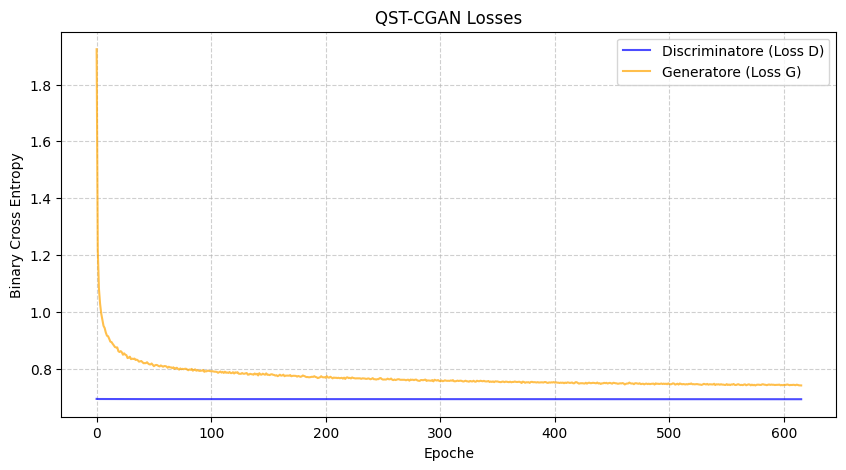

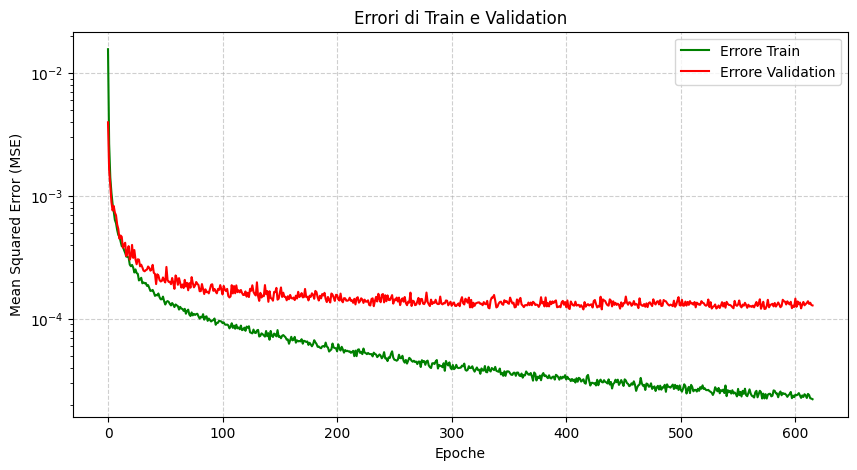

In [139]:
storia = torch.load('storia_addestramento.pt', weights_only=False)

#fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

plt.figure(figsize=(10, 5))

plt.plot(storia['loss_D'], label='Discriminatore (Loss D)', color='blue', alpha=0.7)
plt.plot(storia['loss_G'], label='Generatore (Loss G)', color='orange', alpha=0.7)
plt.title("QST-CGAN Losses")
plt.xlabel("Epoche")
plt.ylabel("Binary Cross Entropy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig("Immagini/losses_qst_cgan.pdf", format='pdf')
plt.show()

plt.figure(figsize=(10, 5))

plt.plot(storia['err_train'], label='Errore Train', color='green')
plt.plot(storia['err_val'], label='Errore Validation', color='red')
plt.title("Errori di Train e Validation")
plt.xlabel("Epoche")
plt.ylabel("Mean Squared Error (MSE)")
plt.yscale('log') 
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig("Immagini/errori_train_val_qst_cgan.pdf", format='pdf')
plt.show()

### Fidelity test set

In [ ]:
generatore.eval()

with torch.no_grad(): 
    rho_previste_test, _ = generatore(X_test)

fidelities_test = []


print("Calcolo della Fidelity sul Test Set")

for i in range(len(y_test)):
    y_vero_flat = y_test[i].numpy()

    rho_prevista_matrice = rho_previste_test[i].numpy()
    y_predetto_flat = np.concatenate([
        rho_prevista_matrice.real.flatten(), 
        rho_prevista_matrice.imag.flatten()
    ])
    
    fedelta = calcola_fidelity_modello(y_vero_flat, y_predetto_flat)
    fidelities_test.append(fedelta)

fidelity_media = np.mean(fidelities_test)
fidelity_std = np.std(fidelities_test)

print(f"Fidelity Media (Test Set): {fidelity_media:.4f} ± {fidelity_std:.4f}")

Calcolo della Fidelity sul Test Set in corso...
----------------------------------------
Fidelity Media (Test Set): 0.9989 ± 0.0015
----------------------------------------


### Esempio heatmap stato vero e ricostruito

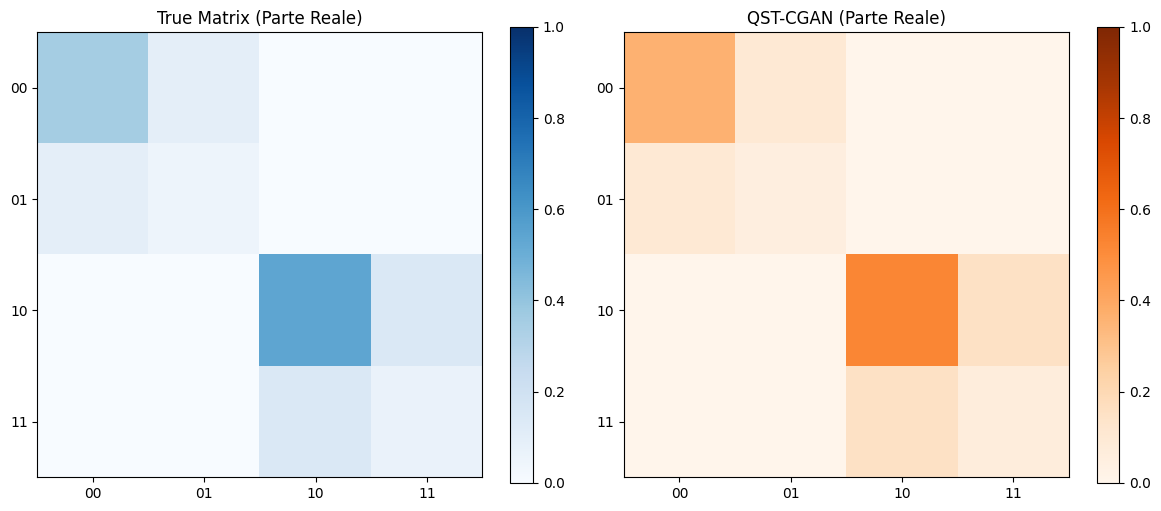

In [131]:
def visualizza_heatmap_2d(y_vero_tensor, rho_gen_tensor, indice=0):
    y_vero_flat = y_vero_tensor[indice].numpy()
    rho_gen_complex = rho_gen_tensor[indice].numpy()
    
    vera_real = (y_vero_flat[:16] + 1j * y_vero_flat[16:]).reshape(4, 4).real
    gen_real = rho_gen_complex.real
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    im1 = ax1.imshow(vera_real, cmap='Blues', vmin=0, vmax=1)
    ax1.set_title("True Matrix (Parte Reale)")
    ax1.set_xticks(np.arange(4)); ax1.set_yticks(np.arange(4))
    ax1.set_xticklabels(['00', '01', '10', '11']); ax1.set_yticklabels(['00', '01', '10', '11'])
    fig.colorbar(im1, ax=ax1)
    
    im2 = ax2.imshow(gen_real, cmap='Oranges', vmin=0, vmax=1)
    ax2.set_title("QST-CGAN (Parte Reale)")
    ax2.set_xticks(np.arange(4)); ax2.set_yticks(np.arange(4))
    ax2.set_xticklabels(['00', '01', '10', '11']); ax2.set_yticklabels(['00', '01', '10', '11'])
    fig.colorbar(im2, ax=ax2)
    
    plt.tight_layout()
    plt.savefig(f"Immagini/heatmap_confronto_{indice}.pdf", format='pdf')
    plt.show()

visualizza_heatmap_2d(y_test, rho_previste_test, indice=0)

### Studi sulla fidelity

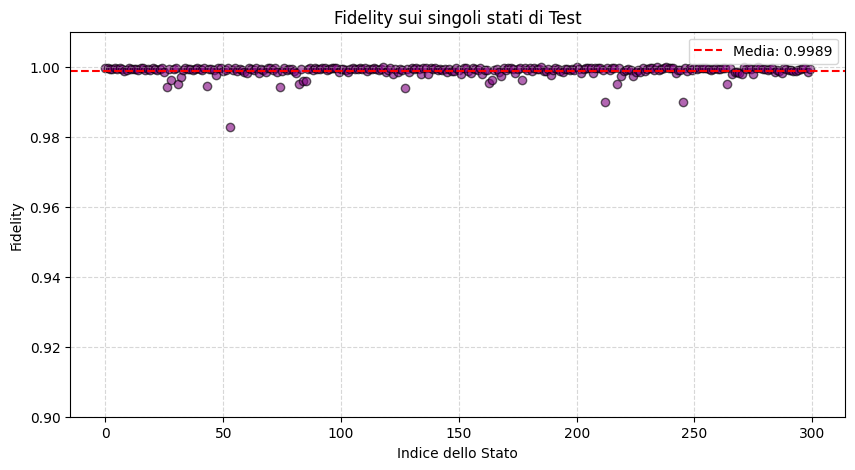

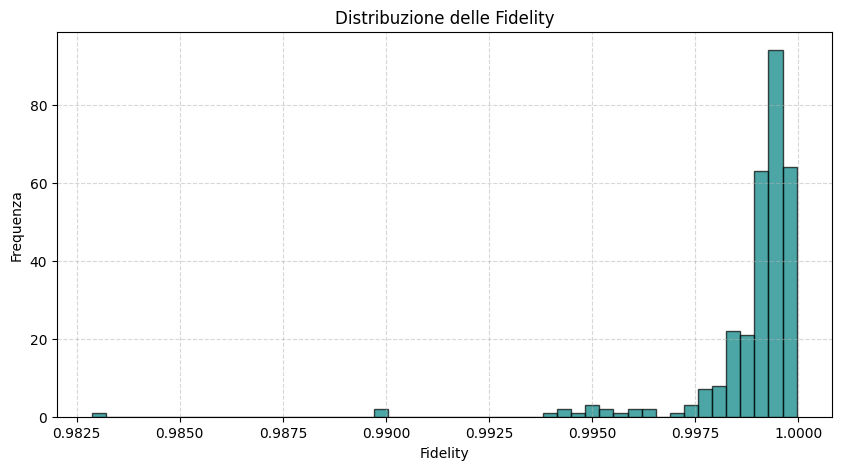

In [144]:
fidelities_array = np.array(fidelities_test)

plt.figure(figsize=(10, 5))

plt.scatter(range(len(fidelities_array)), fidelities_array, color='purple', alpha=0.6, edgecolors='k')
plt.axhline(fidelity_media, color='red', linestyle='--', label=f'Media: {fidelity_media:.4f}')
plt.title("Fidelity sui singoli stati di Test")
plt.xlabel("Indice dello Stato")
plt.ylabel("Fidelity")
plt.ylim(0.90, 1.01) 
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.savefig("Immagini/fidelity_test_set.pdf", format='pdf')
plt.show()

plt.figure(figsize=(10, 5))

plt.hist(fidelities_array, bins=50, color='teal', alpha=0.7, edgecolor='black')
plt.title("Distribuzione delle Fidelity")
plt.xlabel("Fidelity")
plt.ylabel("Frequenza")
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig("Immagini/distribuzione_fidelity_test_set.pdf", format='pdf')
plt.show()

### Andamento fidelity

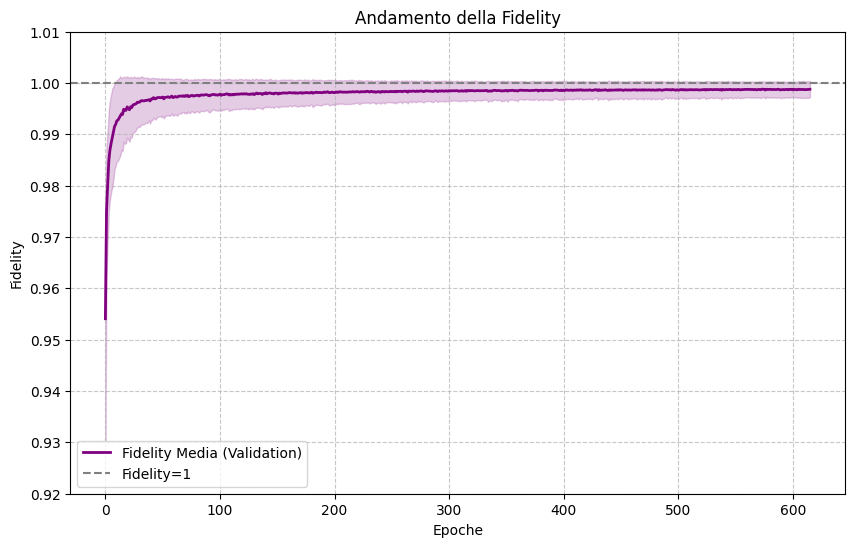

In [150]:
dati = torch.load('storia_addestramento.pt', weights_only=False)

fid_medie = np.array(dati['fidelity_val'])
fid_std = np.array(dati['fidelity_std'])
epoche = np.arange(len(fid_medie))

plt.figure(figsize=(10, 6))

plt.plot(epoche, fid_medie, color='purple', label='Fidelity Media (Validation)', linewidth=2)

plt.fill_between(epoche, fid_medie - fid_std, fid_medie + fid_std, color='purple', alpha=0.2)

plt.axhline(y=1.0, color='gray', linestyle='--', label='Fidelity=1')

plt.title('Andamento della Fidelity')
plt.xlabel('Epoche')
plt.ylabel('Fidelity')
plt.ylim(0.92, 1.01) 
plt.legend()
plt.grid(linestyle='--', alpha=0.7)
plt.savefig("Immagini/andamento_fidelity.pdf", format='pdf')
plt.show()

### Robustezza al rumore

Shots N=   64 -> Fidelity Media: 0.9950 ± 0.0036
Shots N=  128 -> Fidelity Media: 0.9971 ± 0.0019
Shots N=  256 -> Fidelity Media: 0.9982 ± 0.0015
Shots N=  512 -> Fidelity Media: 0.9986 ± 0.0017
Shots N= 1024 -> Fidelity Media: 0.9989 ± 0.0015
Shots N= 2048 -> Fidelity Media: 0.9990 ± 0.0015
Shots N= 4096 -> Fidelity Media: 0.9991 ± 0.0016


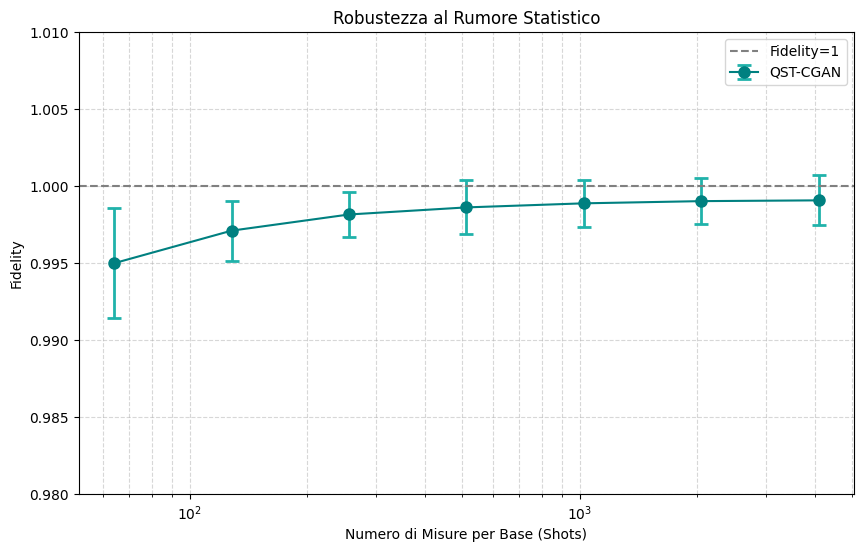

In [157]:
generatore.eval()

rho_vere_complex = y_test[:, :16] + 1j * y_test[:, 16:]
rho_vere_test = rho_vere_complex.reshape(-1, 4, 4)

with torch.no_grad():

    device = next(generatore.parameters()).device
    rho_vere_test = rho_vere_test.to(device)
    
    prob_perfette = generatore.expectation_layer(rho_vere_test).cpu().numpy()

def aggiungi_rumore_shot(prob_esatte, shots_per_base):
    misure_rumorose = np.zeros_like(prob_esatte)
    
    for i in range(prob_esatte.shape[0]):
        for b in range(9): 
            p_base = prob_esatte[i, b*4 : (b+1)*4] 
            
            p_base = np.clip(p_base, 0, 1)
            if np.sum(p_base) > 0:
                p_base = p_base / np.sum(p_base)
            else:
                p_base = np.array([0.25, 0.25, 0.25, 0.25])
            
            conteggi = np.random.multinomial(shots_per_base, p_base)
            misure_rumorose[i, b*4 : (b+1)*4] = conteggi / shots_per_base
            
    return torch.tensor(misure_rumorose, dtype=torch.float32)

livelli_N = [64, 128, 256, 512, 1024, 2048, 4096]
fidelities_medie_N = []
fidelities_std_N = []

y_vero_np = y_test.numpy()

for N in livelli_N:
    X_test_rumoroso = aggiungi_rumore_shot(prob_perfette, N)
    X_test_rumoroso = X_test_rumoroso.to(device)
    
    with torch.no_grad():
        rho_gen_pred, _ = generatore(X_test_rumoroso)
    
    rho_gen_np = rho_gen_pred.cpu().numpy()
    
    fid_livello = []
    for k in range(len(y_vero_np)):
        y_v = y_vero_np[k]
        rho_g = rho_gen_np[k]
        y_pred_f = np.concatenate([rho_g.real.flatten(), rho_g.imag.flatten()])
        
        fid = calcola_fidelity_modello(y_v, y_pred_f)
        fid_livello.append(fid)
        
    media_f = np.mean(fid_livello)
    std_f = np.std(fid_livello)
    
    fidelities_medie_N.append(media_f)
    fidelities_std_N.append(std_f)
    
    print(f"Shots N={N:5d} -> Fidelity Media: {media_f:.4f} ± {std_f:.4f}")

plt.figure(figsize=(10, 6))

plt.errorbar(livelli_N, fidelities_medie_N, yerr=fidelities_std_N, 
             fmt='-o', color='teal', ecolor='lightseagreen', capsize=5, 
             capthick=2, elinewidth=2, markersize=8, label='QST-CGAN')

plt.xscale('log') 
plt.axhline(y=1.0, color='gray', linestyle='--', label='Fidelity=1')

plt.title('Robustezza al Rumore Statistico')
plt.xlabel('Numero di Misure per Base (Shots)')
plt.ylabel('Fidelity')
plt.ylim(0.98, 1.01) 
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.savefig("Immagini/robustezza_rumore_statistico.pdf", format='pdf')
plt.show()

### Ricostruzione stato one-shot

In [ ]:
def ricostruzione_singleshot(generatore, dati_misurati):

    generatore.eval()

    if isinstance(dati_misurati, np.ndarray):
        x_input = torch.tensor(dati_misurati, dtype=torch.float32)
    else:
        x_input = dati_misurati.clone().detach().float()

    if x_input.dim() == 1:
        x_input = x_input.unsqueeze(0)

    device = next(generatore.parameters()).device
    x_input = x_input.to(device)

    with torch.no_grad():
        rho_pred_tensor, _ = generatore(x_input)

    rho_ricostruita = rho_pred_tensor.cpu().numpy()[0]
    
    return rho_ricostruita

/tmp/ipykernel_8133/2396693200.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


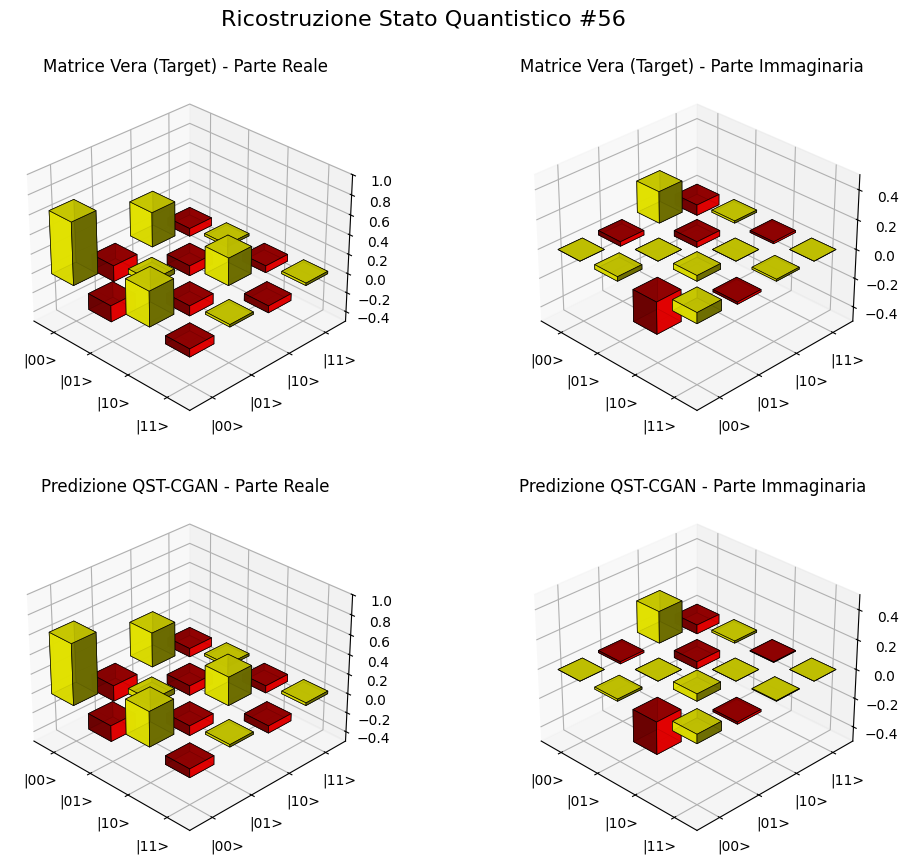

In [160]:

from mpl_toolkits.mplot3d import Axes3D


def plot_cityscape_confronto(rho_vera, rho_cgan, titolo="Confronto Matrici di Densità"):

    fig = plt.figure(figsize=(12, 10))
    fig.suptitle(titolo, fontsize=16, y=0.95)

    labels = ['|00>', '|01>', '|10>', '|11>']
    xpos, ypos = np.meshgrid(np.arange(4), np.arange(4), indexing="ij")
    xpos = xpos.flatten()
    ypos = ypos.flatten()
    zpos = np.zeros(16)
    dx = dy = 0.6 
    matrici = [
        (rho_vera.real, rho_vera.imag, 'Matrice Vera (Target)'),
        (rho_cgan.real, rho_cgan.imag, 'Predizione QST-CGAN')
    ]
    
    plot_idx = 1
    for real_part, imag_part, label in matrici:
        
        ax_real = fig.add_subplot(2, 2, plot_idx, projection='3d')
        dz_real = real_part.flatten()

        colors_real = ['yellow' if val >= 0 else 'red' for val in dz_real]
        
        ax_real.bar3d(xpos, ypos, zpos, dx, dy, dz_real, color=colors_real, alpha=0.9, edgecolor='black', linewidth=0.5)
        ax_real.set_title(f"{label} - Parte Reale")
        ax_real.set_zlim(-0.5, 1.0)
        ax_real.set_xticks(np.arange(4) + dx/2)
        ax_real.set_xticklabels(labels)
        ax_real.set_yticks(np.arange(4) + dy/2)
        ax_real.set_yticklabels(labels)
        plot_idx += 1
        
        ax_imag = fig.add_subplot(2, 2, plot_idx, projection='3d')
        dz_imag = imag_part.flatten()
        colors_imag = ['yellow' if val >= 0 else 'red' for val in dz_imag]
        
        ax_imag.bar3d(xpos, ypos, zpos, dx, dy, dz_imag, color=colors_imag, alpha=0.9, edgecolor='black', linewidth=0.5)
        ax_imag.set_title(f"{label} - Parte Immaginaria")
        ax_imag.set_zlim(-0.5, 0.5) 
        ax_imag.set_xticks(np.arange(4) + dx/2)
        ax_imag.set_xticklabels(labels)
        ax_imag.set_yticks(np.arange(4) + dy/2)
        ax_imag.set_yticklabels(labels)
        plot_idx += 1

        ax_real.view_init(elev=30, azim=-45)
        ax_imag.view_init(elev=30, azim=-45)

    plt.tight_layout()
    plt.savefig("Immagini/confronto_matrici_densita.pdf", format='pdf')
    plt.show()

indice_test = 56

rho_vera_complex = y_test[indice_test, :16] + 1j * y_test[indice_test, 16:]
rho_vera_plot = rho_vera_complex.reshape(4, 4).numpy()

misurazioni_input = X_test[indice_test]

rho_cgan_plot = ricostruzione_singleshot(generatore, misurazioni_input)

plot_cityscape_confronto(rho_vera_plot, rho_cgan_plot, titolo=f"Ricostruzione Stato Quantistico #{indice_test}")

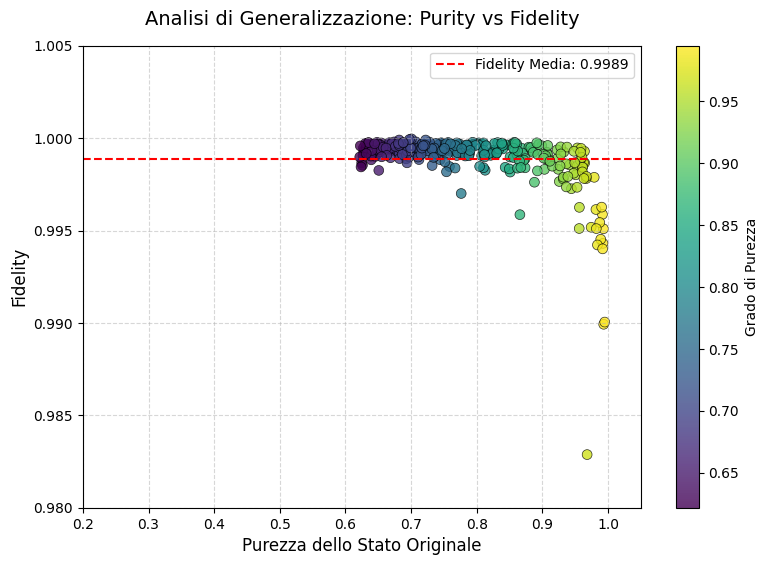

In [163]:
purezze = []
fidelities_cgan = []

y_vero_np = y_test.numpy()

input_full_test = X_test.to(next(generatore.parameters()).device)
with torch.no_grad():
    rho_pred_full, _ = generatore(input_full_test)
rho_pred_np = rho_pred_full.cpu().numpy()

for k in range(len(y_vero_np)):

    rho_vera_complex = y_vero_np[k, :16] + 1j * y_vero_np[k, 16:]
    rho_vera_matrice = rho_vera_complex.reshape(4, 4)

    purezza = np.trace(rho_vera_matrice @ rho_vera_matrice).real
    purezze.append(purezza)
    
    rho_g = rho_pred_np[k]
    y_pred_f = np.concatenate([rho_g.real.flatten(), rho_g.imag.flatten()])
    fid = calcola_fidelity_modello(y_vero_np[k], y_pred_f)
    fidelities_cgan.append(fid)

plt.figure(figsize=(9, 6))

scatter = plt.scatter(purezze, fidelities_cgan, c=purezze, cmap='viridis', 
                      edgecolor='black', linewidth=0.5, alpha=0.8, s=50)

plt.axhline(y=np.mean(fidelities_cgan), color='red', linestyle='--', 
            label=f'Fidelity Media: {np.mean(fidelities_cgan):.4f}')

plt.colorbar(scatter, label='Grado di Purezza')
plt.title("Analisi di Generalizzazione: Purity vs Fidelity", fontsize=14, pad=15)
plt.xlabel("Purezza dello Stato Originale", fontsize=12)
plt.ylabel("Fidelity", fontsize=12)
plt.ylim(0.98, 1.005)
plt.xlim(0.2, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.savefig("Immagini/purity_vs_fidelity.pdf", format='pdf')
plt.show()